# Text Processing and Multiclass Classification

Notebook ini membahas **text processing** dan **multiclass classification** menggunakan scikit-learn. Fokus utama chapter ini adalah bagaimana data teks yang awalnya berbentuk string diubah menjadi representasi numerik agar dapat diproses oleh model machine learning.

Materi utama:
- Introduction to text processing
- Text vectorization dengan Bag of Words dan TF-IDF
- Feature extraction dari teks
- N-grams
- POS tagging sederhana
- Text classification model
- Multiclass classification strategies
- Evaluasi model teks

## Tujuan Pembelajaran

Setelah mempelajari notebook ini, pembaca diharapkan mampu:

- Memahami mengapa teks perlu diproses sebelum digunakan dalam machine learning.
- Menjelaskan konsep corpus, document, token, vocabulary, dan sparse matrix.
- Menggunakan `CountVectorizer` untuk Bag of Words.
- Menggunakan `TfidfVectorizer` untuk memberi bobot kata.
- Memahami stopwords dan n-grams.
- Membangun model text classification menggunakan pipeline.
- Menerapkan strategi multiclass classification seperti One-vs-Rest dan multinomial logistic regression.
- Mengevaluasi model teks menggunakan accuracy, precision, recall, F1-score, dan confusion matrix.

## Persiapan Library

Cell berikut memuat library yang digunakan. Warning diabaikan agar output notebook tetap rapi.

In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

np.random.seed(2024)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 120)

## Ringkasan Chapter

Sebagian besar data di dunia nyata tidak selalu berbentuk angka. Banyak data tersimpan sebagai teks, misalnya email, artikel berita, komentar pengguna, dokumen perusahaan, ulasan produk, dan percakapan online. Masalahnya, komputer tidak dapat langsung memahami teks sebagaimana manusia membacanya.

Agar teks dapat digunakan dalam machine learning, teks perlu diubah menjadi representasi numerik. Proses ini disebut **text vectorization**. Dua pendekatan dasar yang umum digunakan adalah **Bag of Words** dan **TF-IDF**.

Chapter ini juga membahas feature extraction dari teks seperti n-grams dan POS tagging, lalu menerapkan model klasifikasi untuk masalah multiclass.

| Konsep | Penjelasan |
|---|---|
| Corpus | Kumpulan dokumen teks |
| Document | Satu unit teks, misalnya satu review atau satu artikel |
| Token | Unit teks hasil pemecahan, biasanya kata |
| Vocabulary | Daftar token unik dalam corpus |
| Bag of Words | Representasi teks berdasarkan jumlah kemunculan kata |
| TF-IDF | Bobot kata berdasarkan frekuensi dan kelangkaan kata |
| N-gram | Urutan beberapa token berdekatan |
| Multiclass Classification | Klasifikasi dengan lebih dari dua kelas |

## Introduction to Text Processing

Text processing adalah tahap awal untuk mengubah teks mentah menjadi bentuk yang lebih terstruktur. Teks mentah sering memiliki noise, misalnya huruf besar-kecil yang tidak konsisten, tanda baca, angka, stopwords, singkatan, dan variasi penulisan.

Tahapan umum text processing:

1. **Case folding**: mengubah teks menjadi huruf kecil.
2. **Cleaning**: menghapus karakter yang tidak diperlukan.
3. **Tokenization**: memecah teks menjadi token.
4. **Stopword removal**: menghapus kata umum yang kurang informatif.
5. **Vectorization**: mengubah teks menjadi vektor numerik.
6. **Modeling**: melatih model machine learning pada fitur teks.

Pada scikit-learn, banyak proses tersebut dapat dilakukan langsung melalui `CountVectorizer` dan `TfidfVectorizer`.

## Dataset Teks Sintetis

Agar notebook dapat dijalankan tanpa download dataset eksternal, dataset teks dibuat secara sintetis. Dataset ini meniru klasifikasi artikel berita dengan 4 kelas:

- `business`
- `sports`
- `technology`
- `health`

Setiap dokumen berisi kalimat pendek yang merepresentasikan topik tertentu.

In [2]:
texts = [
    # business
    "The company reported higher revenue and strong quarterly profit",
    "Stock market investors reacted to the new banking policy",
    "The central bank increased interest rates to control inflation",
    "A startup raised funding from venture capital firms",
    "The corporation announced a merger with a global finance group",
    "Economic growth slowed as consumer demand weakened",
    "Shareholders approved the annual financial report",
    "The retail company expanded its online sales strategy",
    "Oil prices affected global trade and market confidence",
    "The board discussed investment plans and revenue targets",

    # sports
    "The football team won the championship after a dramatic final match",
    "The basketball player scored thirty points in the playoff game",
    "Tennis fans watched an intense match between top players",
    "The coach praised the team for their defensive performance",
    "A marathon runner broke the national record",
    "The club signed a new striker before the season started",
    "The athlete trained hard for the international tournament",
    "Fans celebrated the victory at the stadium",
    "The referee reviewed the goal using video technology",
    "The swimmer won a gold medal in the final race",

    # technology
    "The software company released a new artificial intelligence platform",
    "Cybersecurity experts warned users about a data breach",
    "The smartphone update improved battery performance and camera quality",
    "Researchers developed a machine learning model for image recognition",
    "The cloud computing service added new storage features",
    "A robotics startup introduced an autonomous delivery system",
    "Developers fixed bugs in the latest application version",
    "The database system improved query speed and reliability",
    "A new processor design increased computing performance",
    "The internet company launched a secure messaging app",

    # health
    "Doctors recommended regular exercise and balanced nutrition",
    "The hospital opened a new emergency care facility",
    "Researchers studied the effect of vaccines on public health",
    "A medical team performed a successful heart surgery",
    "Patients received treatment for respiratory infections",
    "The health agency published new disease prevention guidelines",
    "Nutrition experts discussed the benefits of a healthy diet",
    "The clinic improved access to mental health services",
    "Scientists analyzed symptoms related to viral infection",
    "The nurse monitored patient recovery after treatment"
]

labels = (
    ["business"] * 10 +
    ["sports"] * 10 +
    ["technology"] * 10 +
    ["health"] * 10
)

df_text = pd.DataFrame({
    "text": texts,
    "label": labels
})

df_text.sample(8, random_state=2024)

,text,label
25,A robotics startup introduced an autonomous delivery system,technology
16,The athlete trained hard for the international tournament,sports
22,The smartphone update improved battery performance and camera quality,technology
29,The internet company launched a secure messaging app,technology
33,A medical team performed a successful heart surgery,health
37,The clinic improved access to mental health services,health
36,Nutrition experts discussed the benefits of a healthy diet,health
39,The nurse monitored patient recovery after treatment,health


## Distribusi Kelas

Sebelum modeling, distribusi kelas perlu diperiksa. Dataset seimbang memudahkan interpretasi accuracy. Pada dataset tidak seimbang, accuracy bisa menyesatkan.

label
business      10
sports        10
technology    10
health        10
Name: count, dtype: int64

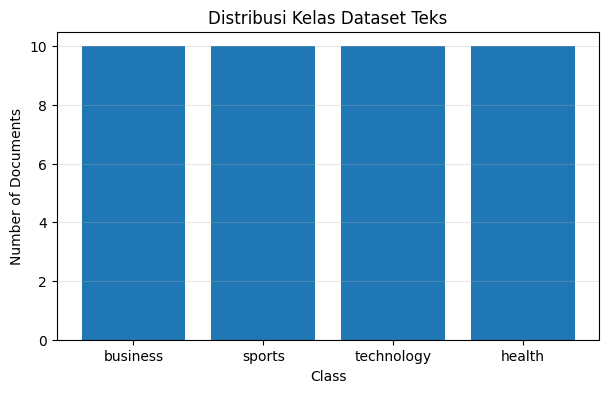

In [3]:
label_counts = df_text["label"].value_counts()

display(label_counts)

plt.figure(figsize=(7, 4))
plt.bar(label_counts.index, label_counts.values)
plt.xlabel("Class")
plt.ylabel("Number of Documents")
plt.title("Distribusi Kelas Dataset Teks")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Cleaning Teks Sederhana

Cleaning bertujuan mengurangi variasi teks yang tidak terlalu penting. Contohnya, huruf kapital dan tanda baca dapat membuat token berbeda padahal maknanya sama.

Contoh:
- `"Company"` dan `"company"` sebaiknya dianggap sama.
- `"profit!"` dan `"profit"` sebaiknya dianggap sama.

Fungsi berikut hanya digunakan untuk demonstrasi. Dalam praktik, cleaning perlu disesuaikan dengan jenis data.

In [4]:
def simple_clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_text["clean_text"] = df_text["text"].apply(simple_clean_text)

df_text[["text", "clean_text", "label"]].head()

,text,clean_text,label
0,The company reported higher revenue and strong quarterly profit,the company reported higher revenue and strong quarterly profit,business
1,Stock market investors reacted to the new banking policy,stock market investors reacted to the new banking policy,business
2,The central bank increased interest rates to control inflation,the central bank increased interest rates to control inflation,business
3,A startup raised funding from venture capital firms,a startup raised funding from venture capital firms,business
4,The corporation announced a merger with a global finance group,the corporation announced a merger with a global finance group,business


## Tokenization

Tokenization adalah proses memecah teks menjadi unit-unit kecil. Unit ini disebut token. Pada contoh sederhana, token biasanya berupa kata.

Contoh:

```text
"the company reported profit"
```

menjadi:

```text
["the", "company", "reported", "profit"]
```

Token inilah yang kemudian digunakan untuk membangun vocabulary.

In [5]:
example_sentence = df_text.loc[0, "clean_text"]
tokens = example_sentence.split()

print("Kalimat:", example_sentence)
print("Tokens:", tokens)

Kalimat: the company reported higher revenue and strong quarterly profit
Tokens: ['the', 'company', 'reported', 'higher', 'revenue', 'and', 'strong', 'quarterly', 'profit']


## Text Vectorization dengan Bag of Words

Bag of Words atau BoW merepresentasikan dokumen berdasarkan frekuensi kemunculan kata. Urutan kata tidak diperhatikan. Model hanya melihat kata apa yang muncul dan berapa kali kata tersebut muncul.

Contoh sederhana:

| Dokumen | company | profit | football |
|---|---:|---:|---:|
| company profit | 1 | 1 | 0 |
| football match | 0 | 0 | 1 |

Kelebihan BoW:
- Sederhana
- Mudah digunakan
- Efektif sebagai baseline text classification

Kekurangan BoW:
- Mengabaikan urutan kata
- Tidak memahami makna semantik
- Vocabulary bisa sangat besar

## Rumus Bag of Words

Jika terdapat dokumen $d$ dan token $t$, nilai Bag of Words dapat ditulis sebagai jumlah kemunculan token tersebut dalam dokumen.

$$
BoW(d,t) = count(t,d)
$$

Keterangan:

- $d$ = dokumen
- $t$ = token
- $count(t,d)$ = jumlah kemunculan token $t$ dalam dokumen $d$

Setiap dokumen diubah menjadi vektor dengan panjang sama dengan jumlah vocabulary.

In [6]:
bow_vectorizer = CountVectorizer(stop_words="english")

X_bow = bow_vectorizer.fit_transform(df_text["clean_text"])

print("Shape BoW matrix:", X_bow.shape)
print("Jumlah vocabulary:", len(bow_vectorizer.get_feature_names_out()))

bow_sample = pd.DataFrame(
    X_bow[:5].toarray(),
    columns=bow_vectorizer.get_feature_names_out()
)

bow_sample.iloc[:, :15]

Shape BoW matrix: (40, 208)
Jumlah vocabulary: 208


,access,added,affected,agency,analyzed,announced,annual,app,application,approved,artificial,athlete,autonomous,balanced,bank
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0


## Sparse Matrix

Hasil vectorization teks biasanya berbentuk sparse matrix. Sparse matrix adalah matriks yang sebagian besar nilainya nol. Ini umum terjadi karena satu dokumen biasanya hanya menggunakan sebagian kecil dari seluruh vocabulary.

Scikit-learn menyimpan hasil vectorization sebagai sparse matrix agar lebih hemat memori.

In [7]:
total_elements = X_bow.shape[0] * X_bow.shape[1]
nonzero_elements = X_bow.nnz
sparsity = 1 - (nonzero_elements / total_elements)

print("Total elemen:", total_elements)
print("Elemen non-zero:", nonzero_elements)
print(f"Sparsity: {sparsity:.2%}")

Total elemen: 8320
Elemen non-zero: 240
Sparsity: 97.12%


## Visualisasi Token Frequency

Visualisasi token frequency membantu melihat kata apa yang paling sering muncul dalam corpus. Pada dataset berita, token yang sering muncul biasanya berhubungan dengan topik utama.

,token,count
0,new,7
1,company,4
2,team,3
3,health,3
4,performance,3
5,improved,3
6,startup,2
7,won,2
8,global,2
9,market,2


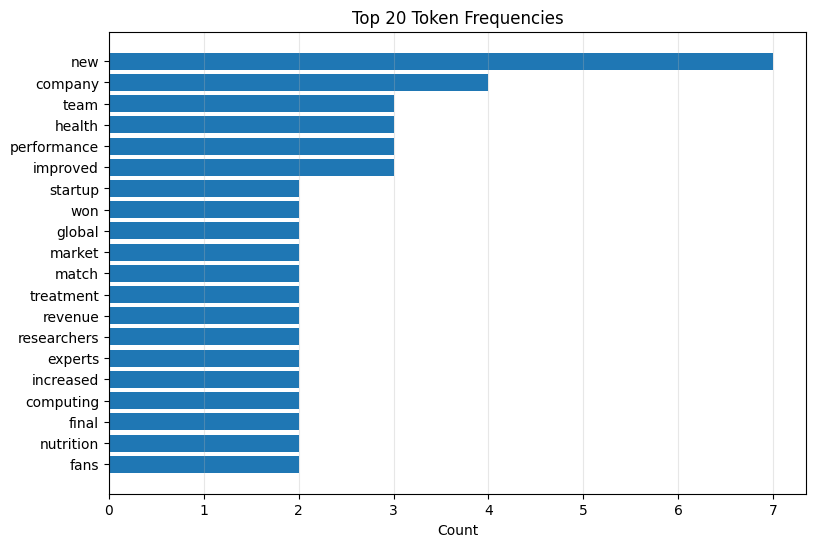

In [8]:
feature_names = bow_vectorizer.get_feature_names_out()
counts = np.asarray(X_bow.sum(axis=0)).ravel()

top_n = 20
top_indices = counts.argsort()[-top_n:][::-1]

top_token_df = pd.DataFrame({
    "token": feature_names[top_indices],
    "count": counts[top_indices]
})

display(top_token_df)

plt.figure(figsize=(9, 6))
plt.barh(top_token_df["token"][::-1], top_token_df["count"][::-1])
plt.xlabel("Count")
plt.title("Top 20 Token Frequencies")
plt.grid(axis="x", alpha=0.3)
plt.show()

## TF-IDF Vectorization

TF-IDF adalah teknik pembobotan kata yang mempertimbangkan dua hal:

1. Seberapa sering kata muncul dalam dokumen.
2. Seberapa langka kata tersebut di seluruh corpus.

Kata yang sering muncul pada satu dokumen tetapi jarang muncul di dokumen lain akan memiliki bobot tinggi. Sebaliknya, kata yang terlalu umum akan memiliki bobot lebih rendah.

## Rumus Term Frequency

Term Frequency mengukur seberapa sering token muncul dalam dokumen.

$$
TF(t,d) = \frac{f_{t,d}}{\sum_{t' \in d} f_{t',d}}
$$

Keterangan:

- $TF(t,d)$ = term frequency token $t$ pada dokumen $d$
- $f_{t,d}$ = jumlah kemunculan token $t$ dalam dokumen $d$
- $\sum_{t' \in d} f_{t',d}$ = jumlah seluruh token dalam dokumen $d$

## Rumus Inverse Document Frequency

Inverse Document Frequency mengukur seberapa jarang token muncul di seluruh corpus.

$$
IDF(t) = \log\left(\frac{N}{df(t)}\right)
$$

Keterangan:

- $N$ = jumlah seluruh dokumen
- $df(t)$ = jumlah dokumen yang mengandung token $t$

Jika sebuah kata muncul di banyak dokumen, nilai IDF-nya lebih kecil.

## Rumus TF-IDF

TF-IDF menggabungkan term frequency dan inverse document frequency.

$$
TFIDF(t,d) = TF(t,d) \times IDF(t)
$$

Keterangan:

- $TFIDF(t,d)$ = bobot token $t$ dalam dokumen $d$
- $TF(t,d)$ = frekuensi token dalam dokumen
- $IDF(t)$ = kelangkaan token dalam corpus

TF-IDF membantu model fokus pada kata yang lebih khas atau lebih informatif.

In [9]:
tfidf_vectorizer = TfidfVectorizer(stop_words="english")

X_tfidf = tfidf_vectorizer.fit_transform(df_text["clean_text"])

print("Shape TF-IDF matrix:", X_tfidf.shape)
print("Jumlah vocabulary:", len(tfidf_vectorizer.get_feature_names_out()))

tfidf_sample = pd.DataFrame(
    X_tfidf[:5].toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

tfidf_sample.iloc[:, :15]

Shape TF-IDF matrix: (40, 208)
Jumlah vocabulary: 208


,access,added,affected,agency,analyzed,announced,annual,app,application,approved,artificial,athlete,autonomous,balanced,bank
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.414925
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
4,0.0,0.0,0.0,0.0,0.0,0.414925,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


## Visualisasi Mean TF-IDF

Mean TF-IDF menunjukkan rata-rata bobot setiap token di seluruh corpus.

,token,mean_tfidf
0,new,0.048004
1,company,0.031810
2,performance,0.027607
3,team,0.026945
4,improved,0.026685
5,health,0.026123
6,fans,0.021003
7,treatment,0.020502
8,increased,0.019661
9,startup,0.019578


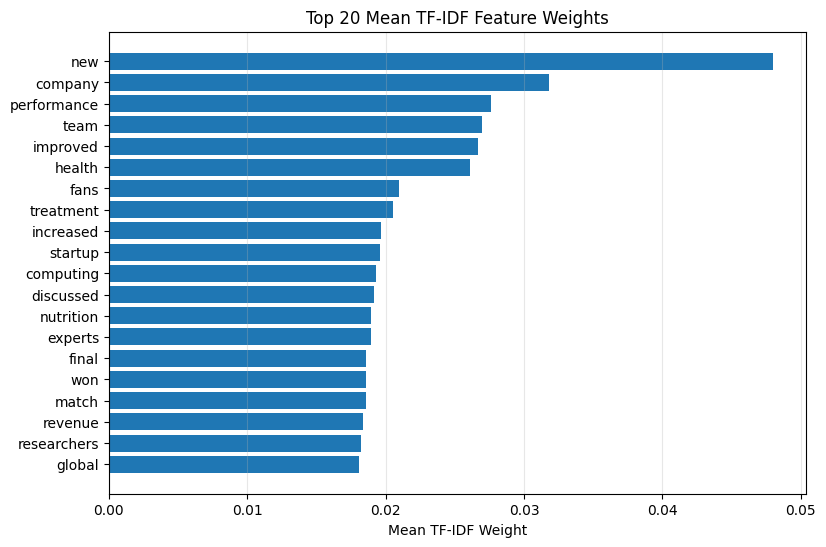

In [10]:
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_means = np.asarray(X_tfidf.mean(axis=0)).ravel()

top_tfidf_indices = tfidf_means.argsort()[-20:][::-1]

top_tfidf_df = pd.DataFrame({
    "token": tfidf_feature_names[top_tfidf_indices],
    "mean_tfidf": tfidf_means[top_tfidf_indices]
})

display(top_tfidf_df)

plt.figure(figsize=(9, 6))
plt.barh(top_tfidf_df["token"][::-1], top_tfidf_df["mean_tfidf"][::-1])
plt.xlabel("Mean TF-IDF Weight")
plt.title("Top 20 Mean TF-IDF Feature Weights")
plt.grid(axis="x", alpha=0.3)
plt.show()

## Perbandingan BoW dan TF-IDF

| Aspek | Bag of Words | TF-IDF |
|---|---|---|
| Nilai fitur | Jumlah kemunculan kata | Bobot kata |
| Memperhatikan kelangkaan kata | Tidak | Ya |
| Mudah dipahami | Sangat mudah | Sedikit lebih kompleks |
| Cocok untuk baseline | Ya | Ya |
| Mengurangi dominasi kata umum | Tidak terlalu | Ya |

BoW cocok untuk baseline sederhana, sedangkan TF-IDF sering memberikan performa lebih baik pada text classification.

## Feature Extraction: N-Grams

N-grams adalah rangkaian $n$ token berurutan. Jika hanya menggunakan unigram, model melihat kata satu per satu. Dengan bigram atau trigram, model dapat menangkap frasa.

Contoh kalimat:

```text
machine learning model
```

Unigram:
```text
machine, learning, model
```

Bigram:
```text
machine learning, learning model
```

N-grams berguna karena beberapa makna muncul dari kombinasi kata, bukan dari kata tunggal saja.

## Rumus Jumlah N-Grams

Jika sebuah dokumen memiliki $L$ token, maka jumlah n-grams yang dapat dibentuk adalah:

$$
Jumlah\ ngram = L - n + 1
$$

Keterangan:

- $L$ = jumlah token dalam dokumen
- $n$ = ukuran n-gram

Contoh: jika $L=5$ dan $n=2$, maka jumlah bigram adalah $5-2+1=4$.

In [11]:
sample_text = "machine learning model improves text classification"
sample_tokens = sample_text.split()

def create_ngrams(tokens, n):
    return [" ".join(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

unigrams = create_ngrams(sample_tokens, 1)
bigrams = create_ngrams(sample_tokens, 2)
trigrams = create_ngrams(sample_tokens, 3)

pd.DataFrame({
    "unigram": pd.Series(unigrams),
    "bigram": pd.Series(bigrams),
    "trigram": pd.Series(trigrams)
})

,unigram,bigram,trigram
0,machine,machine learning,machine learning model
1,learning,learning model,learning model improves
2,model,model improves,model improves text
3,improves,improves text,improves text classification
4,text,text classification,NaN
5,classification,NaN,NaN


## CountVectorizer dengan N-Grams

`ngram_range=(1,2)` berarti vectorizer akan menggunakan unigram dan bigram sekaligus.

In [12]:
ngram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2)
)

X_ngram = ngram_vectorizer.fit_transform(df_text["clean_text"])

print("Shape unigram + bigram matrix:", X_ngram.shape)
print("Jumlah fitur:", len(ngram_vectorizer.get_feature_names_out()))

ngram_features = ngram_vectorizer.get_feature_names_out()
ngram_features[:30]

Shape unigram + bigram matrix: (40, 408)
Jumlah fitur: 408


array(['access', 'access mental', 'added', 'added new', 'affected',
       'affected global', 'agency', 'agency published', 'analyzed',
       'analyzed symptoms', 'announced', 'announced merger', 'annual',
       'annual financial', 'app', 'application', 'application version',
       'approved', 'approved annual', 'artificial',
       'artificial intelligence', 'athlete', 'athlete trained',
       'autonomous', 'autonomous delivery', 'balanced',
       'balanced nutrition', 'bank', 'bank increased', 'banking'],
      dtype=object)

## POS Tagging Sederhana

Part-of-Speech tagging adalah proses memberi label gramatikal pada token, misalnya noun, verb, adjective, dan sebagainya.

Dalam notebook ini, POS tagging dibuat secara sederhana menggunakan aturan kecil agar tidak bergantung pada library eksternal. Pada praktik nyata, POS tagging biasanya dilakukan dengan NLTK, spaCy, atau model NLP lain.

In [13]:
simple_pos_dictionary = {
    "company": "NN", "revenue": "NN", "profit": "NN", "market": "NN", "investors": "NNS",
    "team": "NN", "player": "NN", "match": "NN", "coach": "NN", "fans": "NNS",
    "software": "NN", "data": "NN", "model": "NN", "developers": "NNS", "database": "NN",
    "doctors": "NNS", "hospital": "NN", "patients": "NNS", "health": "NN", "treatment": "NN",
    "reported": "VBD", "won": "VBD", "released": "VBD", "recommended": "VBD",
    "strong": "JJ", "new": "JJ", "successful": "JJ", "secure": "JJ", "healthy": "JJ"
}

def simple_pos_tag(tokens):
    return [(token, simple_pos_dictionary.get(token, "UNK")) for token in tokens]

sample_doc = df_text.loc[0, "clean_text"]
sample_tokens = sample_doc.split()
simple_pos_tag(sample_tokens)

[('the', 'UNK'),
 ('company', 'NN'),
 ('reported', 'VBD'),
 ('higher', 'UNK'),
 ('revenue', 'NN'),
 ('and', 'UNK'),
 ('strong', 'JJ'),
 ('quarterly', 'UNK'),
 ('profit', 'NN')]

## Visualisasi Frekuensi POS Tag Sederhana

Visualisasi berikut menghitung POS tag sederhana dari seluruh corpus. Ini hanya simulasi untuk menunjukkan konsep feature extraction berbasis struktur bahasa.

,POS Tag,Count
0,UNK,282
1,NN,26
3,JJ,11
4,NNS,6
2,VBD,5


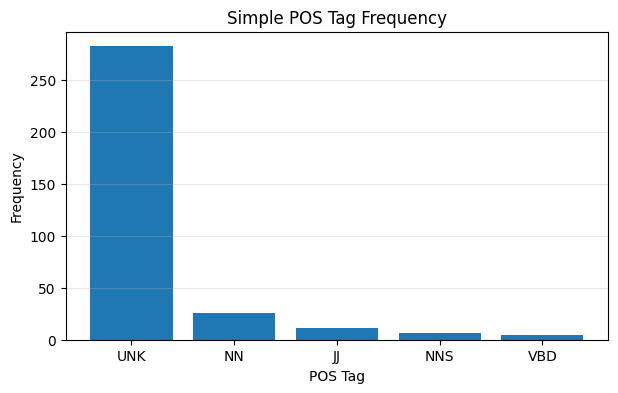

In [14]:
all_tags = []

for text in df_text["clean_text"]:
    tokens = text.split()
    tagged_tokens = simple_pos_tag(tokens)
    all_tags.extend([tag for _, tag in tagged_tokens])

pos_counts = Counter(all_tags)

pos_df = pd.DataFrame(
    pos_counts.items(),
    columns=["POS Tag", "Count"]
).sort_values("Count", ascending=False)

display(pos_df)

plt.figure(figsize=(7, 4))
plt.bar(pos_df["POS Tag"], pos_df["Count"])
plt.xlabel("POS Tag")
plt.ylabel("Frequency")
plt.title("Simple POS Tag Frequency")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Implementing Text Classification Models

Setelah teks diubah menjadi fitur numerik, model machine learning dapat dilatih. Model yang umum digunakan untuk text classification:

| Model | Keterangan |
|---|---|
| Multinomial Naive Bayes | Cepat dan sering kuat untuk teks berbasis count |
| Logistic Regression | Baseline kuat untuk klasifikasi teks |
| Linear SVM | Sering baik untuk data teks berdimensi tinggi |

Pipeline digunakan agar vectorizer dan model tergabung dalam satu workflow.

## Train-Test Split untuk Klasifikasi

Dataset dibagi menjadi training dan test set dengan stratifikasi agar proporsi kelas tetap seimbang.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    df_text["clean_text"],
    df_text["label"],
    test_size=0.3,
    random_state=2024,
    stratify=df_text["label"]
)

print("Jumlah training:", len(X_train))
print("Jumlah testing:", len(X_test))
print("Kelas:", sorted(set(y_train)))

Jumlah training: 28
Jumlah testing: 12
Kelas: ['business', 'health', 'sports', 'technology']


## Model 1: CountVectorizer + Multinomial Naive Bayes

Multinomial Naive Bayes sering digunakan untuk text classification karena cocok dengan fitur berupa count atau frekuensi kata.

In [16]:
nb_pipe = Pipeline([
    ("vectorizer", CountVectorizer(stop_words="english")),
    ("model", MultinomialNB())
])

nb_pipe.fit(X_train, y_train)

y_pred_nb = nb_pipe.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_nb))

nb_report = pd.DataFrame(
    classification_report(y_test, y_pred_nb, output_dict=True)
).transpose()

nb_report

Accuracy: 0.3333333333333333


,precision,recall,f1-score,support
business,0.200000,0.333333,0.250000,3.000000
health,0.500000,0.666667,0.571429,3.000000
sports,0.500000,0.333333,0.400000,3.000000
technology,0.000000,0.000000,0.000000,3.000000
accuracy,0.333333,0.333333,0.333333,0.333333
macro avg,0.300000,0.333333,0.305357,12.000000
weighted avg,0.300000,0.333333,0.305357,12.000000


## Model 2: TF-IDF + Logistic Regression

Logistic Regression sering menjadi baseline yang kuat untuk klasifikasi teks. Dengan TF-IDF, model dapat menggunakan bobot kata yang lebih informatif.

In [17]:
logreg_pipe = Pipeline([
    ("vectorizer", TfidfVectorizer(stop_words="english")),
    ("model", LogisticRegression(max_iter=1000))
])

logreg_pipe.fit(X_train, y_train)

y_pred_logreg = logreg_pipe.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_logreg))

logreg_report = pd.DataFrame(
    classification_report(y_test, y_pred_logreg, output_dict=True)
).transpose()

logreg_report

Accuracy: 0.3333333333333333


,precision,recall,f1-score,support
business,0.200000,0.333333,0.250000,3.000000
health,0.500000,0.666667,0.571429,3.000000
sports,0.500000,0.333333,0.400000,3.000000
technology,0.000000,0.000000,0.000000,3.000000
accuracy,0.333333,0.333333,0.333333,0.333333
macro avg,0.300000,0.333333,0.305357,12.000000
weighted avg,0.300000,0.333333,0.305357,12.000000


## Model 3: TF-IDF + Linear SVM

Linear SVM sering efektif untuk data teks karena data teks biasanya memiliki banyak fitur dan bersifat sparse.

In [18]:
svm_pipe = Pipeline([
    ("vectorizer", TfidfVectorizer(stop_words="english")),
    ("model", LinearSVC())
])

svm_pipe.fit(X_train, y_train)

y_pred_svm = svm_pipe.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))

svm_report = pd.DataFrame(
    classification_report(y_test, y_pred_svm, output_dict=True)
).transpose()

svm_report

Accuracy: 0.3333333333333333


,precision,recall,f1-score,support
business,0.200000,0.333333,0.250000,3.000000
health,0.500000,0.666667,0.571429,3.000000
sports,0.500000,0.333333,0.400000,3.000000
technology,0.000000,0.000000,0.000000,3.000000
accuracy,0.333333,0.333333,0.333333,0.333333
macro avg,0.300000,0.333333,0.305357,12.000000
weighted avg,0.300000,0.333333,0.305357,12.000000


## Perbandingan Model Text Classification

Tabel berikut membandingkan performa tiga model.

In [19]:
model_comparison = pd.DataFrame([
    {
        "Model": "CountVectorizer + MultinomialNB",
        "Accuracy": accuracy_score(y_test, y_pred_nb),
        "Macro F1": f1_score(y_test, y_pred_nb, average="macro")
    },
    {
        "Model": "TF-IDF + LogisticRegression",
        "Accuracy": accuracy_score(y_test, y_pred_logreg),
        "Macro F1": f1_score(y_test, y_pred_logreg, average="macro")
    },
    {
        "Model": "TF-IDF + LinearSVC",
        "Accuracy": accuracy_score(y_test, y_pred_svm),
        "Macro F1": f1_score(y_test, y_pred_svm, average="macro")
    }
]).sort_values("Macro F1", ascending=False)

model_comparison

,Model,Accuracy,Macro F1
0,CountVectorizer + MultinomialNB,0.333333,0.305357
1,TF-IDF + LogisticRegression,0.333333,0.305357
2,TF-IDF + LinearSVC,0.333333,0.305357


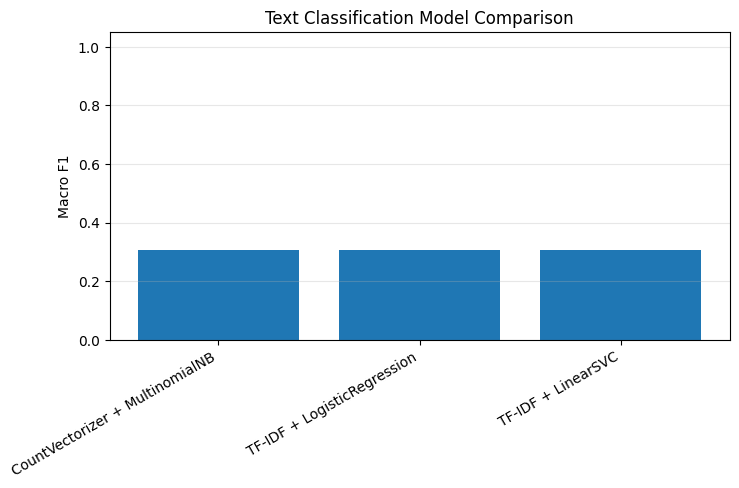

In [20]:
plt.figure(figsize=(8, 4))
plt.bar(model_comparison["Model"], model_comparison["Macro F1"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Macro F1")
plt.title("Text Classification Model Comparison")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.show()

## Multiclass Classification Strategies

Multiclass classification adalah klasifikasi dengan lebih dari dua kelas. Pada dataset ini, terdapat empat kelas: business, sports, technology, dan health.

Strategi multiclass yang umum:

| Strategi | Penjelasan |
|---|---|
| One-vs-Rest | Melatih satu classifier untuk setiap kelas melawan semua kelas lain |
| One-vs-One | Melatih classifier untuk setiap pasangan kelas |
| Multinomial | Model mempelajari semua kelas secara langsung |

Scikit-learn biasanya menangani multiclass classification secara otomatis, tetapi One-vs-Rest dapat dibuat eksplisit dengan `OneVsRestClassifier`.

## Rumus One-vs-Rest

Jika terdapat $K$ kelas, One-vs-Rest melatih $K$ classifier biner.

$$
Classifier_k: class_k \ vs \ all\ other\ classes
$$

Prediksi akhir dipilih berdasarkan skor terbesar:

$$
\hat{y} = \arg\max_k s_k(x)
$$

Keterangan:

- $K$ = jumlah kelas
- $s_k(x)$ = skor classifier untuk kelas ke-$k$
- $\hat{y}$ = kelas prediksi akhir

In [21]:
ovr_pipe = Pipeline([
    ("vectorizer", TfidfVectorizer(stop_words="english")),
    ("model", OneVsRestClassifier(LogisticRegression(max_iter=1000)))
])

ovr_pipe.fit(X_train, y_train)

y_pred_ovr = ovr_pipe.predict(X_test)

print("Accuracy One-vs-Rest:", accuracy_score(y_test, y_pred_ovr))

ovr_report = pd.DataFrame(
    classification_report(y_test, y_pred_ovr, output_dict=True)
).transpose()

ovr_report

Accuracy One-vs-Rest: 0.3333333333333333


,precision,recall,f1-score,support
business,0.200000,0.333333,0.250000,3.000000
health,0.500000,0.666667,0.571429,3.000000
sports,0.500000,0.333333,0.400000,3.000000
technology,0.000000,0.000000,0.000000,3.000000
accuracy,0.333333,0.333333,0.333333,0.333333
macro avg,0.300000,0.333333,0.305357,12.000000
weighted avg,0.300000,0.333333,0.305357,12.000000


## Multinomial Logistic Regression

Multinomial logistic regression menggunakan softmax untuk menghasilkan probabilitas pada setiap kelas.

## Rumus Softmax

Untuk kelas ke-$k$, probabilitas dapat ditulis sebagai:

$$
P(y=k|x)=\frac{e^{z_k}}{\sum_{j=1}^{K}e^{z_j}}
$$

Keterangan:

- $K$ = jumlah kelas
- $z_k$ = skor linear untuk kelas ke-$k$
- $P(y=k|x)$ = probabilitas data masuk kelas ke-$k$

Prediksi akhir:

$$
\hat{y}=\arg\max_k P(y=k|x)
$$

In [22]:
multinomial_pipe = Pipeline([
    ("vectorizer", TfidfVectorizer(stop_words="english")),
    ("model", LogisticRegression(max_iter=1000, solver="lbfgs"))
])

multinomial_pipe.fit(X_train, y_train)

y_pred_multinomial = multinomial_pipe.predict(X_test)

print("Accuracy Multinomial Logistic Regression:", accuracy_score(y_test, y_pred_multinomial))

Accuracy Multinomial Logistic Regression: 0.3333333333333333


## Evaluating Text Models

Evaluasi model teks perlu menggunakan metrik yang sesuai. Accuracy berguna ketika kelas seimbang, tetapi precision, recall, dan F1-score lebih informatif jika kelas tidak seimbang.

Metrik utama:

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

$$
Precision = \frac{TP}{TP + FP}
$$

$$
Recall = \frac{TP}{TP + FN}
$$

$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

## Confusion Matrix

Confusion matrix menunjukkan kelas mana yang sering tertukar oleh model.

In [23]:
best_text_model = svm_pipe
best_pred = y_pred_svm

labels_order = sorted(df_text["label"].unique())

cm = confusion_matrix(y_test, best_pred, labels=labels_order)

cm_df = pd.DataFrame(
    cm,
    index=[f"True {label}" for label in labels_order],
    columns=[f"Predicted {label}" for label in labels_order]
)

cm_df

,Predicted business,Predicted health,Predicted sports,Predicted technology
True business,1,1,0,1
True health,0,2,1,0
True sports,2,0,1,0
True technology,2,1,0,0


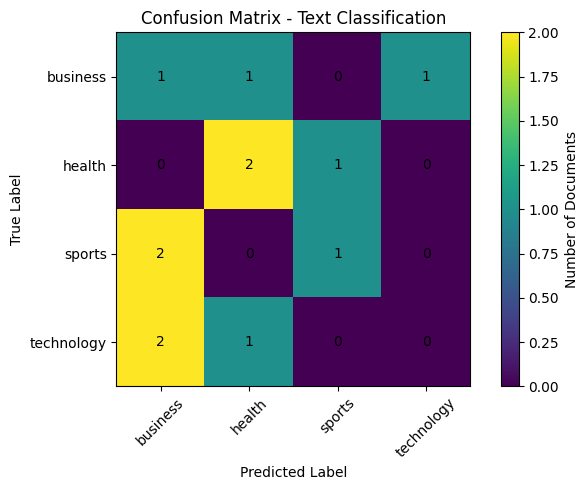

In [24]:
plt.figure(figsize=(7, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - Text Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(labels_order)), labels_order, rotation=45)
plt.yticks(np.arange(len(labels_order)), labels_order)
plt.colorbar(label="Number of Documents")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## Cross-Validation

Cross-validation memberi gambaran performa model pada beberapa pembagian data. Karena dataset contoh kecil, nilai performa dapat bervariasi.

In [25]:
cv_scores = cross_val_score(
    svm_pipe,
    df_text["clean_text"],
    df_text["label"],
    cv=4,
    scoring="f1_macro"
)

print("CV Macro F1 scores:", cv_scores)
print(f"Mean CV Macro F1: {cv_scores.mean():.3f}")
print(f"Standard Deviation: {cv_scores.std():.3f}")

CV Macro F1 scores: [0.625      0.45416667 0.25       0.70952381]
Mean CV Macro F1: 0.510
Standard Deviation: 0.176


## Grid Search untuk Text Pipeline

Grid search dapat digunakan untuk tuning parameter vectorizer dan model secara bersamaan.

Contoh parameter:
- `ngram_range`
- `min_df`
- `C` pada Linear SVM

In [26]:
grid_pipe = Pipeline([
    ("vectorizer", TfidfVectorizer(stop_words="english")),
    ("model", LinearSVC())
])

param_grid = {
    "vectorizer__ngram_range": [(1, 1), (1, 2)],
    "vectorizer__min_df": [1, 2],
    "model__C": [0.1, 1, 10]
}

grid_search = GridSearchCV(
    grid_pipe,
    param_grid,
    cv=4,
    scoring="f1_macro"
)

grid_search.fit(df_text["clean_text"], df_text["label"])

print("Best parameters:", grid_search.best_params_)
print(f"Best CV Macro F1: {grid_search.best_score_:.3f}")

Best parameters: {'model__C': 10, 'vectorizer__min_df': 1, 'vectorizer__ngram_range': (1, 1)}
Best CV Macro F1: 0.533


In [27]:
grid_results = pd.DataFrame(grid_search.cv_results_)

grid_results[[
    "param_vectorizer__ngram_range",
    "param_vectorizer__min_df",
    "param_model__C",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score").head(10)

,param_vectorizer__ngram_range,param_vectorizer__min_df,param_model__C,mean_test_score,std_test_score,rank_test_score
8,"(1, 1)",1,10.0,0.532887,0.194703,1
1,"(1, 2)",1,0.1,0.521230,0.090477,2
5,"(1, 2)",1,1.0,0.510863,0.102964,3
0,"(1, 1)",1,0.1,0.510863,0.102964,3
4,"(1, 1)",1,1.0,0.509673,0.175892,5
9,"(1, 2)",1,10.0,0.480506,0.147757,6
3,"(1, 2)",2,0.1,0.270139,0.077682,7
2,"(1, 1)",2,0.1,0.270139,0.077682,7
7,"(1, 2)",2,1.0,0.263605,0.077043,9
6,"(1, 1)",2,1.0,0.263605,0.077043,9


## Interpretasi Fitur Model

Model linear seperti Logistic Regression memiliki koefisien yang dapat digunakan untuk melihat token mana yang mendorong prediksi ke kelas tertentu.

Contoh berikut mengambil model Logistic Regression dan menampilkan token paling berpengaruh untuk setiap kelas.

In [28]:
interpret_pipe = Pipeline([
    ("vectorizer", TfidfVectorizer(stop_words="english")),
    ("model", LogisticRegression(max_iter=1000))
])

interpret_pipe.fit(df_text["clean_text"], df_text["label"])

vectorizer = interpret_pipe.named_steps["vectorizer"]
classifier = interpret_pipe.named_steps["model"]

feature_names = np.array(vectorizer.get_feature_names_out())
classes = classifier.classes_

top_features = []

for class_index, class_name in enumerate(classes):
    coef = classifier.coef_[class_index]
    top_idx = np.argsort(coef)[-8:][::-1]

    for idx in top_idx:
        top_features.append({
            "class": class_name,
            "feature": feature_names[idx],
            "coefficient": coef[idx]
        })

top_features_df = pd.DataFrame(top_features)
top_features_df

,class,feature,coefficient
0,business,revenue,0.412047
1,business,market,0.398406
2,business,global,0.398153
3,business,shareholders,0.258241
4,business,approved,0.258241
5,business,financial,0.258241
6,business,report,0.258241
7,business,annual,0.258241
8,health,health,0.582142
9,health,treatment,0.458143


## Analisis Interpretasi Fitur

Token dengan koefisien tinggi menunjukkan kata yang kuat mengarah ke kelas tertentu. Misalnya, kata seperti `market`, `revenue`, atau `bank` dapat mengarah ke business, sedangkan `football`, `team`, dan `match` mengarah ke sports.

Interpretasi seperti ini membantu memahami apakah model belajar pola yang masuk akal atau hanya menangkap noise.

## Ringkasan Konsep Penting

| Konsep | Penjelasan |
|---|---|
| Text Processing | Mengubah teks mentah menjadi format yang siap diproses |
| Corpus | Kumpulan dokumen teks |
| Token | Unit teks seperti kata |
| Vocabulary | Daftar token unik |
| Stopwords | Kata umum yang sering kurang informatif |
| Bag of Words | Representasi teks berbasis hitungan token |
| Sparse Matrix | Matriks dengan banyak nilai nol |
| TF-IDF | Bobot kata berdasarkan frekuensi dan kelangkaan |
| N-grams | Urutan beberapa token |
| POS Tagging | Pelabelan jenis kata |
| Text Classification | Klasifikasi dokumen berdasarkan isi teks |
| Multiclass Classification | Klasifikasi lebih dari dua kelas |
| One-vs-Rest | Satu classifier untuk setiap kelas |
| Softmax | Fungsi probabilitas untuk multiclass |
| Confusion Matrix | Ringkasan prediksi benar dan salah antar kelas |

## Kesimpulan Chapter

Chapter ini menjelaskan bahwa data teks perlu diproses dan diubah menjadi representasi numerik sebelum digunakan dalam machine learning. Teknik dasar seperti Bag of Words dan TF-IDF memungkinkan model membaca teks dalam bentuk vektor.

Poin penting dari chapter ini:

- Teks mentah perlu dibersihkan, ditokenisasi, dan divektorisasi.
- `CountVectorizer` mengubah teks menjadi jumlah kemunculan token.
- `TfidfVectorizer` memberi bobot lebih besar pada token yang lebih khas.
- Stopwords dapat dihapus untuk mengurangi kata yang kurang informatif.
- N-grams membantu menangkap konteks frasa.
- POS tagging dan feature extraction membantu memahami struktur teks.
- Pipeline membuat proses vectorization dan modeling lebih rapi.
- Logistic Regression, Naive Bayes, dan Linear SVM dapat digunakan untuk text classification.
- Multiclass classification dapat dilakukan dengan One-vs-Rest atau pendekatan multinomial.
- Evaluasi model teks perlu melihat accuracy, precision, recall, F1-score, dan confusion matrix.

Secara keseluruhan, text processing adalah tahap penting dalam natural language processing karena menjadi jembatan antara data teks manusia dan model machine learning.